In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

input_a = Path("benchmark_summaries/benchmark_summary_arxiv_PDXEARCH_20260318_151835.csv")
input_b = Path("benchmark_summaries/benchmark_summary_arxiv_PDXEARCH_20260318_151707.csv")

label_a = "PDXearch Row Group - Sorted"
label_b = "PDXearch Row Group - Shuffled"

components = [
    "avg_calc_index_scan_duration",
    "avg_filtered_sequential_scan_duration",
    "avg_planner",
    "avg_physical_planner",
    "avg_all_optimizers",
]

title = "Benchmark Timing Breakdown"
ylabel = "Seconds"
figsize = (8, 5)

output = Path("benchmark_summaries/stacked_compare_pdxearch_rowgroup_vs_global_sorted_notebook.png")


Saved plot to: benchmark_summaries/stacked_compare_pdxearch_rowgroup_vs_global_sorted_notebook.png


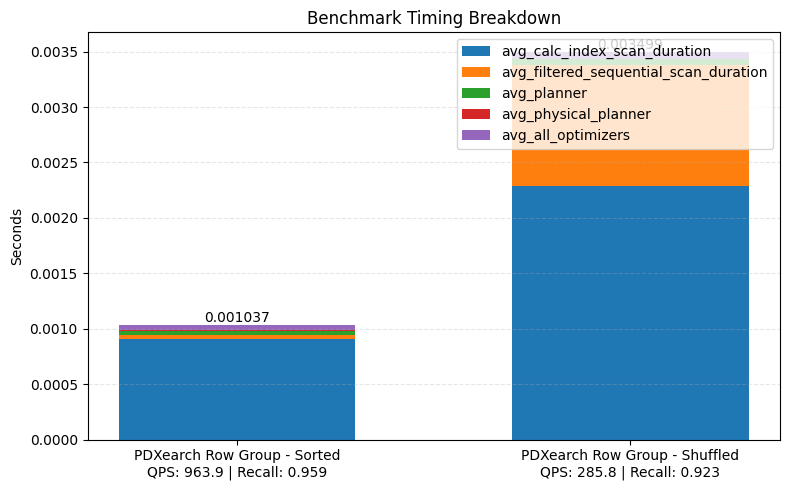

In [14]:
def load_summary(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    df = pd.read_csv(path)
    if df.empty:
        raise ValueError(f"CSV is empty: {path}")
    return df


def extract_component_means(df: pd.DataFrame, cols: list[str], path: Path) -> list[float]:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"{path} is missing required columns: {', '.join(missing)}")
    return [float(pd.to_numeric(df[c], errors="coerce").mean()) for c in cols]


def extract_avg_qps_and_recall(df: pd.DataFrame, path: Path) -> tuple[float, float]:
    required = ["avg_latency", "avg_recall"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(
            f"{path} is missing required columns for QPS/recall labels: {', '.join(missing)}"
        )

    avg_latency = float(pd.to_numeric(df["avg_latency"], errors="coerce").mean())
    avg_recall = float(pd.to_numeric(df["avg_recall"], errors="coerce").mean())

    if avg_latency <= 0:
        raise ValueError(f"{path} has non-positive avg_latency={avg_latency}, cannot compute QPS")

    avg_qps = 1.0 / avg_latency
    return avg_qps, avg_recall


df_a = load_summary(input_a)
df_b = load_summary(input_b)
vals_a = extract_component_means(df_a, components, input_a)
vals_b = extract_component_means(df_b, components, input_b)
qps_a, recall_a = extract_avg_qps_and_recall(df_a, input_a)
qps_b, recall_b = extract_avg_qps_and_recall(df_b, input_b)

x = [0, 1]
labels = [
    f"{label_a}\nQPS: {qps_a:.1f} | Recall: {recall_a:.3f}",
    f"{label_b}\nQPS: {qps_b:.1f} | Recall: {recall_b:.3f}",
]
width = 0.6

fig, ax = plt.subplots(figsize=figsize)
bottom_a = 0.0
bottom_b = 0.0

for idx, component in enumerate(components):
    color = f"C{idx % 10}"
    ax.bar(x[0], vals_a[idx], width=width, bottom=bottom_a, color=color, label=component)
    ax.bar(x[1], vals_b[idx], width=width, bottom=bottom_b, color=color)
    bottom_a += vals_a[idx]
    bottom_b += vals_b[idx]

totals = [sum(vals_a), sum(vals_b)]
for i, total in enumerate(totals):
    ax.text(i, total, f"{total:.6f}", ha="center", va="bottom")

ax.set_xticks(x, labels)
ax.set_ylabel(ylabel)
ax.set_title(title)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(loc="upper right")
fig.tight_layout()

output.parent.mkdir(parents=True, exist_ok=True)
# fig.savefig(output, dpi=150)
print(f"Saved plot to: {output}")
plt.show()
